In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
babybabel_summary_path = 'blimp_results/gpt_babybabel_without_books_150000/gpt_babybabel_without_books_15000.pt_blimp_nl_summary.csv'
stories_summary_path = 'blimp_results/gpt_chiscor_sftw_150000/gpt_chiscor_sftw_15000.pt_blimp_nl_summary.csv'
babybabel_macro_path = 'blimp_results/gpt_babybabel_without_books_150000/gpt_babybabel_without_books_15000.pt_blimp_nl_macro_accuracy.txt'
stories_macro_path = 'blimp_results/gpt_chiscor_sftw_150000/gpt_chiscor_sftw_15000.pt_blimp_nl_macro_accuracy.txt'

In [4]:
babybabel_summary = pd.read_csv(babybabel_summary_path)
stories_summary = pd.read_csv(stories_summary_path)

In [5]:
with open(babybabel_macro_path, 'r') as f:
    babybabel_macro = float(f.readlines()[0].strip('\n'))
    
with open(stories_macro_path, 'r') as f:
    story_macro = float(f.readlines()[0].strip('\n'))
    
print(f'Babybabel macro-average', babybabel_macro)
print(f'Story averago', story_macro)

Babybabel macro-average 0.743896
Story averago 0.755674


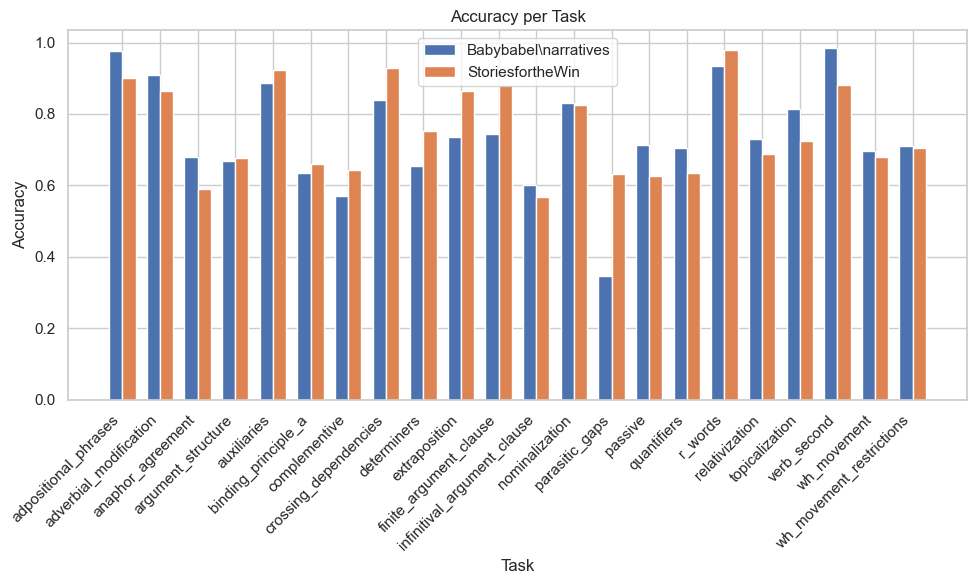

In [6]:
# Merge on task so rows align
df = pd.merge(babybabel_summary, stories_summary, on="subset", suffixes=("_babybabel", "_sftw"))

tasks = df["subset"]
acc1 = df["accuracy_babybabel"]
acc2 = df["accuracy_sftw"]

x = np.arange(len(tasks))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, acc1, width, label="Babybabel\\narratives")
plt.bar(x + width/2, acc2, width, label="StoriesfortheWin")

plt.xticks(x, tasks, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Task")
plt.title("Accuracy per Task")
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
df

,subset,n_examples_babybabel,n_correct_babybabel,accuracy_babybabel,n_examples_sftw,n_correct_sftw,accuracy_sftw
0,adpositional_phrases,200,195,0.975000,200,180,0.900000
1,adverbial_modification,200,182,0.910000,200,173,0.865000
2,anaphor_agreement,200,136,0.680000,200,118,0.590000
3,argument_structure,800,534,0.667500,800,542,0.677500
4,auxiliaries,500,443,0.886000,500,461,0.922000
5,binding_principle_a,200,127,0.635000,200,132,0.660000
6,complementive,500,285,0.570000,500,321,0.642000
7,crossing_dependencies,100,84,0.840000,100,93,0.930000
8,determiners,400,262,0.655000,400,301,0.752500
9,extraposition,300,221,0.736667,300,259,0.863333


In [8]:
import pandas as pd
import numpy as np
import glob

results_bb = []

for file in glob.glob("blimp_results/gpt_babybabel_without_books_150000/*.csv"):
    if file == 'blimp_results/gpt_babybabel_without_books_150000/gpt_babybabel_without_books_15000.pt_blimp_nl_summary.csv':
        print('ok')
        continue
    df = pd.read_csv(file)

    acc = df["correct"].mean()
    n = len(df)

    se = np.sqrt(acc * (1 - acc) / n)

    results_bb.append({
        "subset": file.split(".")[1].replace("pt_",""),
        "accuracy": acc,
        "n": n,
        "se": se,
        "ci95": 1.96 * se
    })

summary_bb = pd.DataFrame(results_bb)
summary_bb

ok


,subset,accuracy,n,se,ci95
0,r_words,0.935000,200,0.017432,0.034167
1,adverbial_modification,0.910000,200,0.020236,0.039663
2,adpositional_phrases,0.975000,200,0.011040,0.021638
3,anaphor_agreement,0.680000,200,0.032985,0.064650
4,nominalization,0.830000,200,0.026561,0.052060
5,auxiliaries,0.886000,500,0.014213,0.027857
6,passive,0.712500,400,0.022630,0.044354
7,binding_principle_a,0.635000,200,0.034042,0.066723
8,infinitival_argument_clause,0.602222,900,0.016315,0.031977
9,relativization,0.730000,300,0.025632,0.050239


In [9]:
results_sftw = []

for file in glob.glob("blimp_results/gpt_chiscor_sftw_150000/*.csv"):
    if file == 'blimp_results/gpt_chiscor_sftw_150000/gpt_chiscor_sftw_15000.pt_blimp_nl_summary.csv':
        print('ok')
        continue
    df = pd.read_csv(file)

    acc = df["correct"].mean()
    n = len(df)

    se = np.sqrt(acc * (1 - acc) / n)

    results_sftw.append({
        "subset": file.split(".")[1].replace("pt_",""),
        "accuracy": acc,
        "n": n,
        "se": se,
        "ci95": 1.96 * se
    })

summary_sftw = pd.DataFrame(results_sftw)


ok


In [10]:
# Merge on task so rows align
df = pd.merge(summary_bb, summary_sftw, on="subset", suffixes=("_babybabel", "_sftw"))
df

,subset,accuracy_babybabel,n_babybabel,se_babybabel,ci95_babybabel,accuracy_sftw,n_sftw,se_sftw,ci95_sftw
0,r_words,0.935000,200,0.017432,0.034167,0.980000,200,0.009899,0.019403
1,adverbial_modification,0.910000,200,0.020236,0.039663,0.865000,200,0.024164,0.047360
2,adpositional_phrases,0.975000,200,0.011040,0.021638,0.900000,200,0.021213,0.041578
3,anaphor_agreement,0.680000,200,0.032985,0.064650,0.590000,200,0.034778,0.068165
4,nominalization,0.830000,200,0.026561,0.052060,0.825000,200,0.026868,0.052661
5,auxiliaries,0.886000,500,0.014213,0.027857,0.922000,500,0.011993,0.023506
6,passive,0.712500,400,0.022630,0.044354,0.627500,400,0.024174,0.047380
7,binding_principle_a,0.635000,200,0.034042,0.066723,0.660000,200,0.033496,0.065653
8,infinitival_argument_clause,0.602222,900,0.016315,0.031977,0.566667,900,0.016518,0.032375
9,relativization,0.730000,300,0.025632,0.050239,0.686667,300,0.026780,0.052489


In [11]:
import pandas as pd

df_long = pd.DataFrame({
    "subset": list(df["subset"]) * 2,
    "model": ["babybabel"] * len(df) + ["sftw"] * len(df),
    "accuracy": list(df["accuracy_babybabel"]) + list(df["accuracy_sftw"]),
    "ci95": list(df["ci95_babybabel"]) + list(df["ci95_sftw"])
})
df_long

,subset,model,accuracy,ci95
0,r_words,babybabel,0.935000,0.034167
1,adverbial_modification,babybabel,0.910000,0.039663
2,adpositional_phrases,babybabel,0.975000,0.021638
3,anaphor_agreement,babybabel,0.680000,0.064650
4,nominalization,babybabel,0.830000,0.052060
5,auxiliaries,babybabel,0.886000,0.027857
6,passive,babybabel,0.712500,0.044354
7,binding_principle_a,babybabel,0.635000,0.066723
8,infinitival_argument_clause,babybabel,0.602222,0.031977
9,relativization,babybabel,0.730000,0.050239


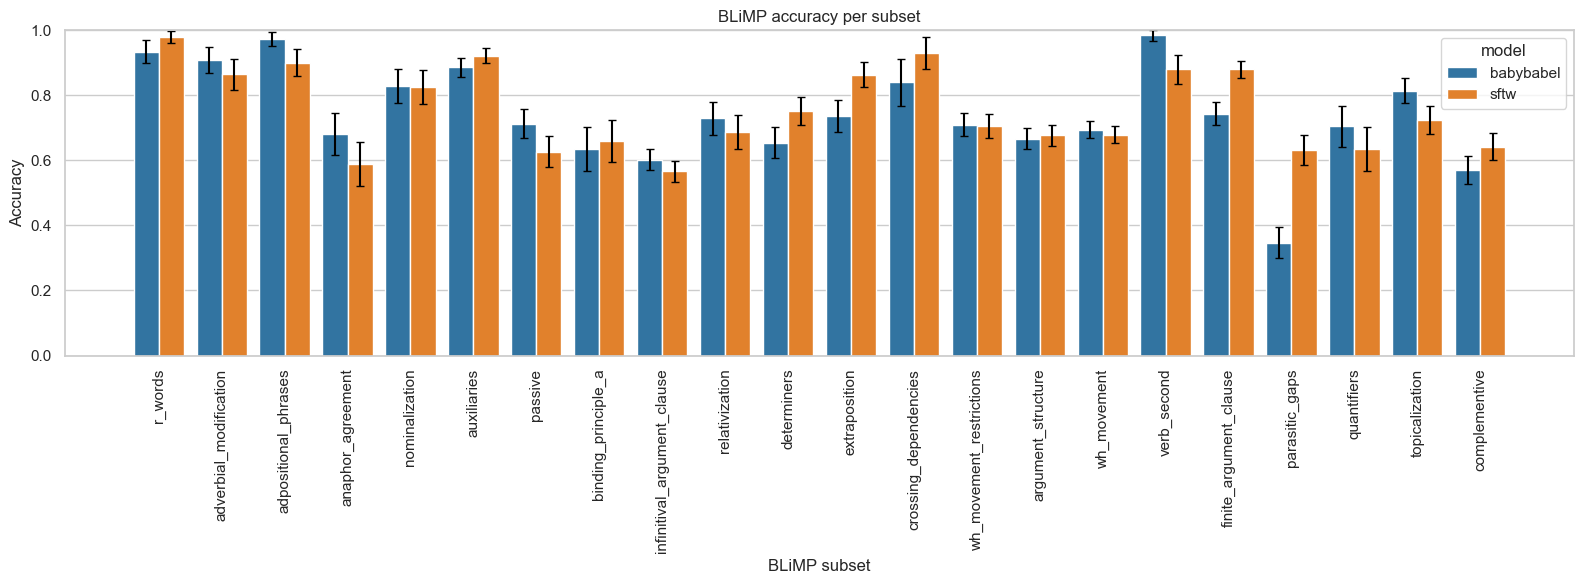

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(16,6))

sns.barplot(
    data=df_long,
    x="subset",
    y="accuracy",
    hue="model",
    palette="tab10",
    ax=ax
)

# number of subsets and models
n_subsets = df["subset"].nunique()
models = df_long["model"].unique()
n_models = len(models)

# bar width used by seaborn
bar_width = 0.8 / n_models

# add error bars manually
for i, model in enumerate(models):
    subset_data = df_long[df_long["model"] == model]

    x_positions = np.arange(n_subsets) - 0.4 + bar_width/2 + i * bar_width

    ax.errorbar(
        x_positions,
        subset_data["accuracy"],
        yerr=subset_data["ci95"],
        fmt="none",
        color="black",
        capsize=3
    )

ax.set_ylim(0,1)
ax.set_xlabel("BLiMP subset")
ax.set_ylabel("Accuracy")
ax.set_title("BLiMP accuracy per subset")

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('blimp_results.pdf')